In [19]:
import pickle

X_train, X_test, y_train, y_test = pickle.load(open('../artifacts/preprocessed_data.pkl', 'rb'))
feature_names = pickle.load(open('../artifacts/feature_names.pkl', 'rb'))

In [20]:
# Step 1: Import libraries

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
# Create model

model = LogisticRegression(max_iter=1000)

# Train model

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [22]:
# Predict on test data

y_pred = model.predict(X_test)

print(y_pred[:10])   # first 10 predictions

[0 0 0 0 1 1 0 0 0 0]


In [23]:
# Accuracy score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7653061224489796


In [24]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[195  52]
 [ 17  30]]


In [25]:
# Classification Report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.37      0.64      0.47        47

    accuracy                           0.77       294
   macro avg       0.64      0.71      0.66       294
weighted avg       0.83      0.77      0.79       294



In [26]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient', ascending=False)

print(importance.head(10))

                             Feature  Coefficient
10                     MonthlyIncome     2.193356
13                          OverTime     0.916711
21                    YearsAtCompany     0.621541
38           JobRole_Human Resources     0.588229
39     JobRole_Laboratory Technician     0.498032
23           YearsSinceLastPromotion     0.496374
45      JobRole_Sales Representative     0.417982
44           JobRole_Sales Executive     0.338893
2                   DistanceFromHome     0.326911
26  BusinessTravel_Travel_Frequently     0.307210


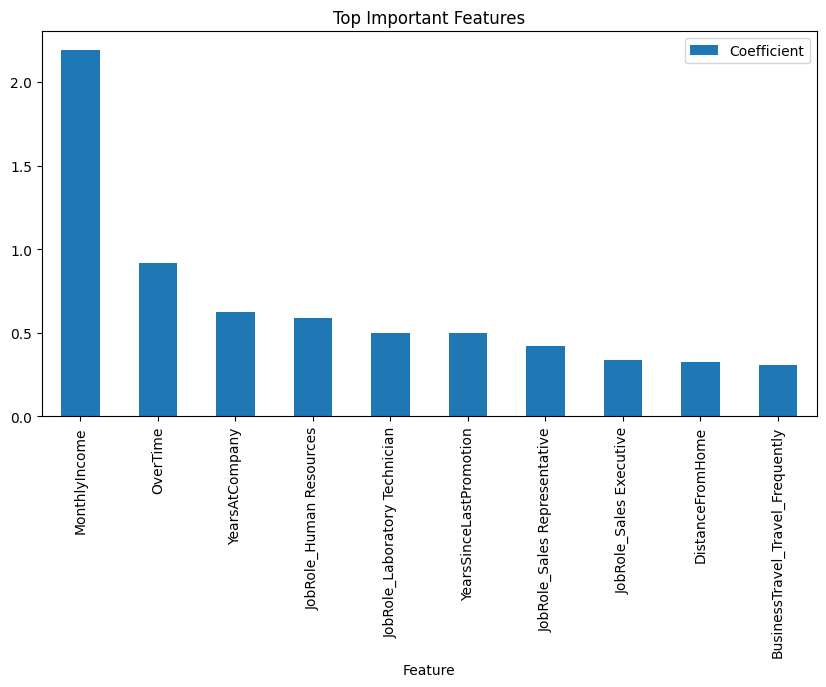

In [27]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Important Features")
plt.show()

In [28]:
pickle.dump(model, open('../artifacts/logistic_model.pkl', 'wb'))

print("Model Saved Successfully!")

Model Saved Successfully!


In [29]:
from sklearn.metrics import roc_auc_score

# Probability predictions
y_prob = model.predict_proba(X_test)[:,1]

# ROC-AUC score
roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.795417348608838


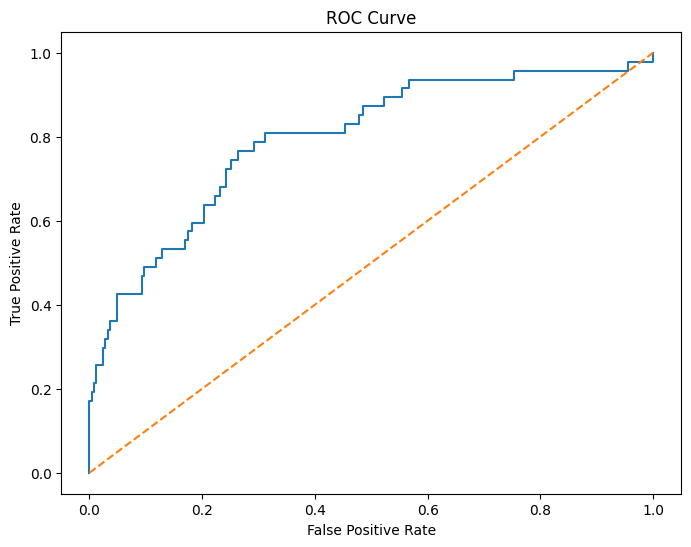

In [30]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.76708861 0.78227848 0.81218274 0.83756345 0.79949239]
Average CV Score: 0.7997211334575596


In [32]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best Score: 0.8012439760971535


In [33]:
best_model = LogisticRegression(
    C=grid.best_params_['C'],
    solver='liblinear',
    max_iter=1000
)

best_model.fit(X_train, y_train)

print("Final Optimized Model Ready!")

Final Optimized Model Ready!


In [34]:
pickle.dump(
    best_model,
    open('../artifacts/final_model.pkl', 'wb')
)

print("Final Model Saved!")

Final Model Saved!


In [35]:
sample_prediction = best_model.predict(X_test[:5])

print(sample_prediction)

[0 0 0 0 1]


In [36]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_proba_lr = model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lr)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold_lr = thresholds[best_idx]

print(f"Best threshold: {best_threshold_lr:.4f}")
print(f"Best F1 at this threshold: {f1_scores[best_idx]:.4f}")

pickle.dump(model, open('../artifacts/logistic_model.pkl', 'wb'))
pickle.dump(best_threshold_lr, open('../artifacts/logistic_threshold.pkl', 'wb'))

print("Saved to artifacts/")

Best threshold: 0.8017
Best F1 at this threshold: 0.5063
Saved to artifacts/
